# XGBoost Model

XGBoost uses lag and rolling features created by the preprocessing notebook.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(PROJECT_ROOT / "src"))

from forecast_utils import *
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from xgboost import XGBRegressor

df = pd.read_csv(DATA_DIR / 'xgboost_data.csv', parse_dates=['timestamp'])
train, test = train_test_split_time(df)
feature_cols = [c for c in df.columns if c not in ['timestamp', 'target']]
X_train, y_train = train[feature_cols], train['target']
X_test, y_test = test[feature_cols], test['target']
print(X_train.shape, X_test.shape)

(7132, 16) (1783, 16)


In [2]:
model = XGBRegressor(n_estimators=250, max_depth=4, learning_rate=0.05, subsample=0.9, colsample_bytree=0.9, objective='reg:squarederror', random_state=42, n_jobs=-1)
model.fit(X_train, y_train)
pred = model.predict(X_test)
mse = mean_squared_error(y_test, pred)
metrics = {
    'MAE': mean_absolute_error(y_test, pred),
    'MSE': mse,
    'RMSE': np.sqrt(mse),
    'R2': r2_score(y_test, pred),
}
metrics

{'MAE': 0.004325427150847147,
 'MSE': 9.549752026371049e-05,
 'RMSE': np.float64(0.00977228326767652),
 'R2': 0.3800809065558436}

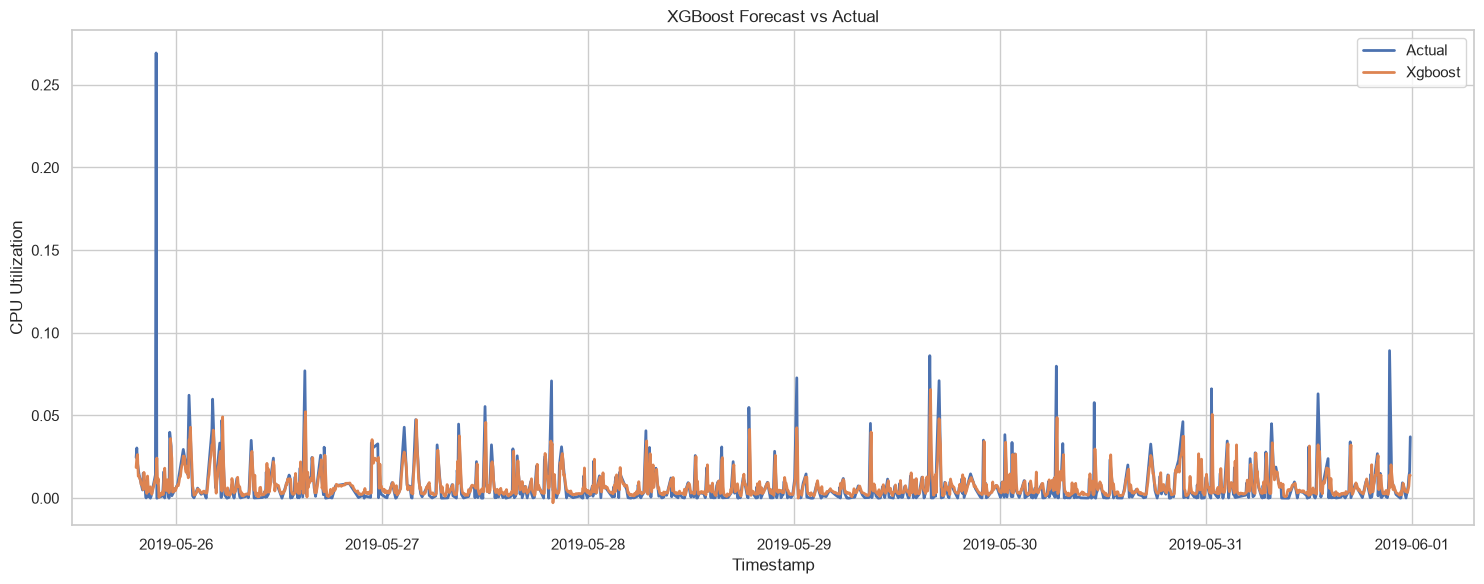

,timestamp,actual,xgboost
7132,2019-05-25 19:20:00,0.024589,0.018560
7133,2019-05-25 19:25:00,0.030365,0.024508
7134,2019-05-25 19:30:00,0.021067,0.026346
7135,2019-05-25 19:35:00,0.017873,0.013256
7136,2019-05-25 19:40:00,0.014679,0.013616


In [3]:
path, pred_df = save_prediction_csv('xgboost', test['timestamp'], y_test, pred)
plot_actual_predicted(pred_df, 'xgboost', 'XGBoost Forecast vs Actual', 'xgboost_forecast.png')
pred_df.head()

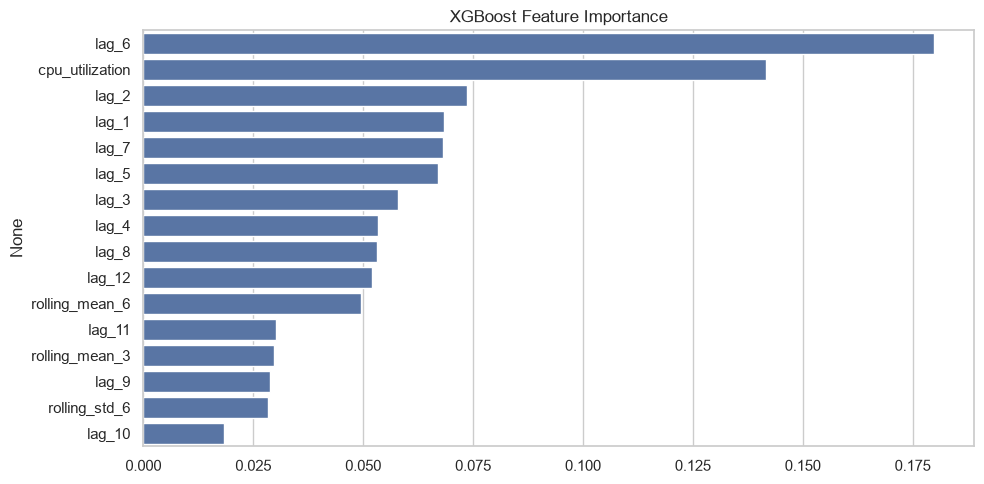

In [4]:
importance = pd.Series(model.feature_importances_, index=feature_cols).sort_values(ascending=False)
plt.figure(figsize=(10, 5))
sns.barplot(x=importance.values, y=importance.index)
plt.title('XGBoost Feature Importance')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'xgboost_feature_importance.png', dpi=160)
plt.show()